# Analysing NN simulations

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we analyse the simulation done on Dardel (or running _NN_FS_IMP_sim_taus_80p_v0.py_). We load the .h5 file and run some analysis. Some of these have to be integrated directly in the simulation scripts.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.NN_simulation_analysis_helper import *
from utils.Plots_helper import *

In [4]:
file_name='testing_80p_v0/ictal_interictal_synchro_IMP_cr_Z0_-50_tau_r_08.h5'
#file_name='testing_80p_v0/ictal_interictal_synchro_IMP_cr_Z0_-50_tau_r_1.h5'

In [5]:
data=load_ictal_interictal_synchro_h5(file_name)

In [6]:
meta = data[0]
ictal = data[1]
interictal = data[2]
synch = data[3]

In [7]:
pops = ['FS','RS','IMP']

In [8]:
sim_duration = data[0]['sim_duration']*b2.second
bin_size = 0.1 * b2.second
bin_edges = np.arange(0, sim_duration + bin_size, bin_size)

time_bins = time_bins = bin_edges[:-1] + (bin_size/b2.second / 2) 

### Extracting ictal and interictal regimes

In [9]:
#ictal['FS'], interictal['FS']

In [10]:
ictal_FS = ictal['FS']
ictal_RS = ictal['RS']
ictal_IMP = ictal['IMP']

interictal_FS = interictal['FS']
interictal_RS = interictal['RS']
interictal_IMP = interictal['IMP']

In [11]:
ictal = {'FS':ictal_FS, 'RS':ictal_RS, 'IMP':ictal_IMP}
interictal = {'FS':interictal_FS, 'RS':interictal_RS, 'IMP':interictal_IMP}

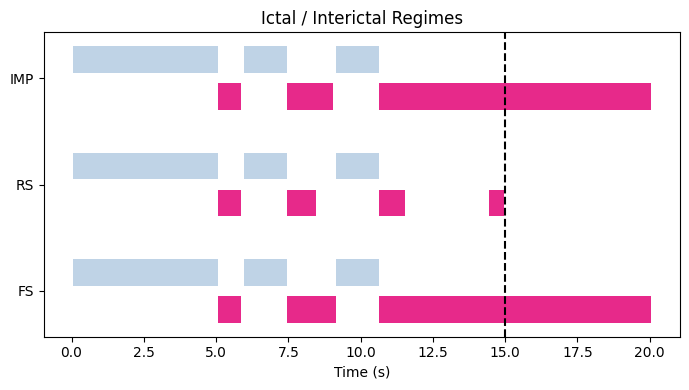

In [12]:
fig = plot_regime_timeline_h5(ictal, interictal, pops, split_time = data[0]['p_end'])

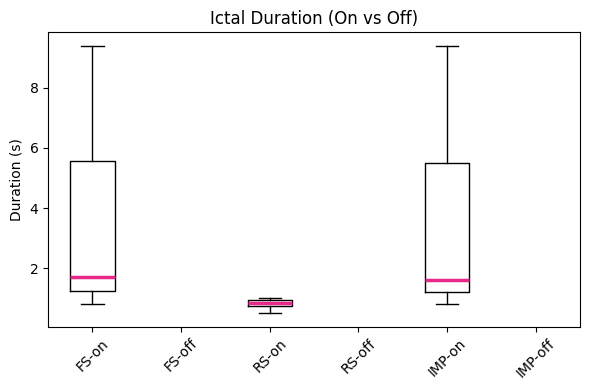

In [13]:
fig = plot_ictal_regime_duration_h5(ictal, pops, split_time = data[0]['p_end'])

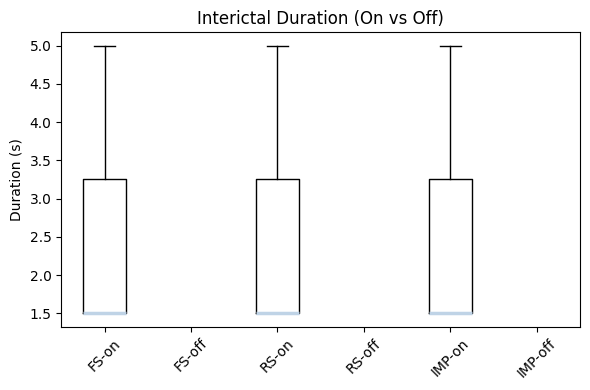

In [14]:
fig = plot_interictal_regime_duration_h5(interictal, pops, split_time = data[0]['p_end'])

## Synchronicity

In [15]:
sync_FS = data[3]['FS']
sync_RS = data[3]['RS']
sync_IMP = data[3]['IMP']

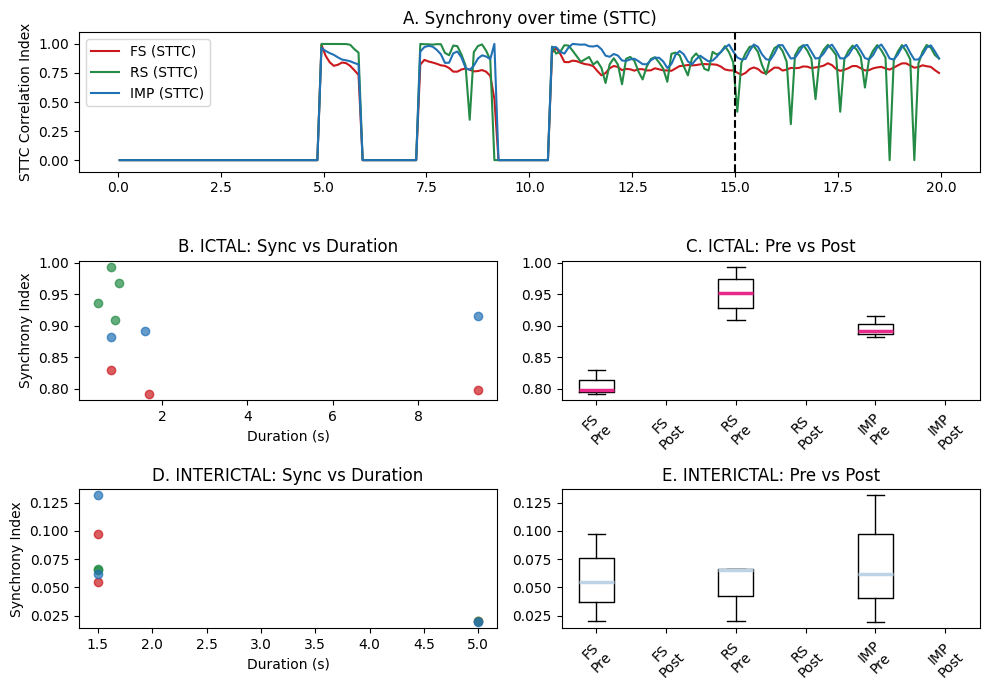

In [16]:
fig = plot_synchrony_panels_h5(pops, ictal, interictal,
                            sync_FS, sync_RS, sync_IMP,
                            time_bins, split_time=data[0]['p_end'])